# 2 Introduction to Keras.

In [1]:
pip install keras tensorflow


Identifying the version of Keras.

In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0



Manual Gradient Calculation in Numpy

In [3]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
    return x ** 2
# Manual derivative (f’(x) = 2x)
def gradient(x):
    return 2 * x
# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
    x -= learning_rate * gradient(x)
print(f"x: {x}, f(x): {f(x)}")

x: 0.5368709120000001, f(x): 0.2882303761517119



Gradient Computations with Keras.

In [4]:
import tensorflow as tf
x = tf.Variable(5.0) # Trainable variable
with tf.GradientTape() as tape:
    y = x ** 2 # y = x^2
    grad = tape.gradient(y, x) # Computes dy/dx automatically
print(grad.numpy()) # Output: 10.0

10.0


Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).

In [5]:
import numpy as np
import tensorflow as tf
import time
# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)
# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.0673680305480957
TensorFlow Time: 0.1377241611480713


# Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

Load and Preprocess the Data:

# TASK 1 – LOAD & PREPROCESS DATA
Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image. Hints:

• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification.

In [6]:
import tensorflow as tf
print(tf.__version__)
print(tf.keras.__version__)

2.19.0
3.13.2


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import zipfile
import os

# ── Adjust this path to where you uploaded the zip on your Drive ──────────
zip_path    = "/content/drive/MyDrive/Colab Notebooks/AI/Copy of devnagari digit.zip"
extract_dir = '/content/devnagari_dataset'

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

# Dataset lives inside the extracted subfolder
dataset_root = os.path.join(extract_dir, 'DevanagariHandwrittenDigitDataset')

train_dir = os.path.join(dataset_root, 'Train')
test_dir  = os.path.join(dataset_root, 'Test')

print('Train folder:', train_dir)
print('Test folder :', test_dir)
print('Classes found:', sorted(os.listdir(train_dir)))

Train folder: /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train
Test folder : /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Test
Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [15]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from PIL import Image

# Image dimensions
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))   # digit_0 ... digit_9
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert('L')              # grayscale
            img = img.resize((img_width, img_height))             # 28x28
            img = np.array(img) / 255.0                           # normalise
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

# Reshape for Keras: (samples, 28, 28, 1)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test  = x_test.reshape(-1,  img_height, img_width, 1)

# One-hot encode labels (10 Devnagari digit classes)
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print(f'Training set : {x_train.shape}, Labels: {y_train.shape}')
print(f'Testing set  : {x_test.shape},  Labels: {y_test.shape}')



Training set : (17000, 28, 28, 1), Labels: (17000, 10)
Testing set  : (3000, 28, 28, 1),  Labels: (3000, 10)


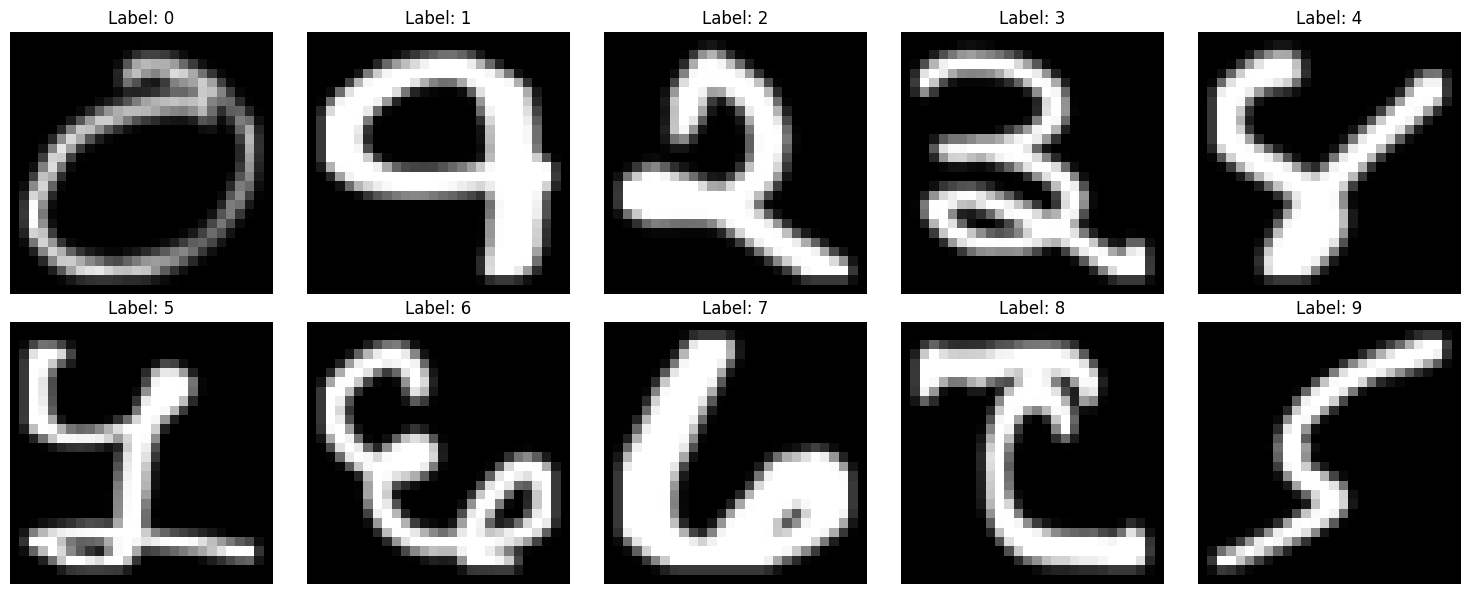

In [16]:
import matplotlib.pyplot as plt

# Show one sample image per class (digit 0-9)
unique_indices = [np.where(np.argmax(y_train, axis=1) == i)[0][0] for i in range(10)]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(unique_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {i}', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Task 2: Build the FCN Model

Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons: – 1st hidden layer: 64 neurons – 2nd hidden layer: 128 neurons – 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units and a softmax activation function.

In [17]:
from tensorflow import keras

num_classes = 10
input_shape = (28, 28, 1)

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),                          # 28x28x1 -> 784
    keras.layers.Dense(64,  activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(num_classes, activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model
Model Compilation

• Choose an appropriate optimizer (Adam), loss function (categorical crossentropy), and evaluation metric (accuracy

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the Model
Model Training • Use the model.fit() function to train the model. Set the batch size to 128 and the number of epochs to 20. • Use validation split (validation split=0.2) to monitor the model’s performance on validation data. • Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [19]:
# Shuffle training data to remove ordered-label bias (0-9 sequence)
indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)
x_train = x_train[indices]
y_train = y_train[indices]


batch_size = 128
epochs = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath='model_at_epoch_{epoch}.keras'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4),
]

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4601 - loss: 1.8477 - val_accuracy: 0.7741 - val_loss: 1.0084
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8238 - loss: 0.6521 - val_accuracy: 0.8697 - val_loss: 0.4538
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8959 - loss: 0.3653 - val_accuracy: 0.9035 - val_loss: 0.3159
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9326 - loss: 0.2519 - val_accuracy: 0.9306 - val_loss: 0.2318
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9495 - loss: 0.1898 - val_accuracy: 0.9426 - val_loss: 0.1894
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9619 - loss: 0.1501 - val_accuracy: 0.9553 - val_loss: 0.1560
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9667 - loss: 0.1236 - val_accuracy: 0.9568 - val_loss: 0.1439
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9735 - loss: 0.1006 - val_accuracy: 0

# Task 5: Evaluate the Model
Model Evaluation • After training, evaluate the model using model.evaluate() on the test set to check the test accuracy and loss.

In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9777 - loss: 0.0891
Test Accuracy: 0.9776666760444641
Test Loss: 0.08906788378953934


# Task 6: Save and Load the Model
Model Saving and Loading • Save the trained model to an .h5 file using model.save(). • Load the saved model and re-evaluate its performance on the test set.

In [21]:
# 1. Save the model
model.save('devnagari_model.keras')
print('Model saved to devnagari_model.keras')

# 2. Load the model
loaded_model = tf.keras.models.load_model('devnagari_model.keras')

# 3. Re-compile the model
loaded_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Re-evaluate performance
loss, acc = loaded_model.evaluate(x_test, y_test)
print(f'Re-evaluated Accuracy: {acc:.4f}')

Model saved to devnagari_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9777 - loss: 0.0891
Re-evaluated Accuracy: 0.9777


# Task 7: Predictions
Making Predictions • Use model.predict() to make predictions on test images. • Convert the model’s predicted probabilities to digit labels using np.argmax().

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


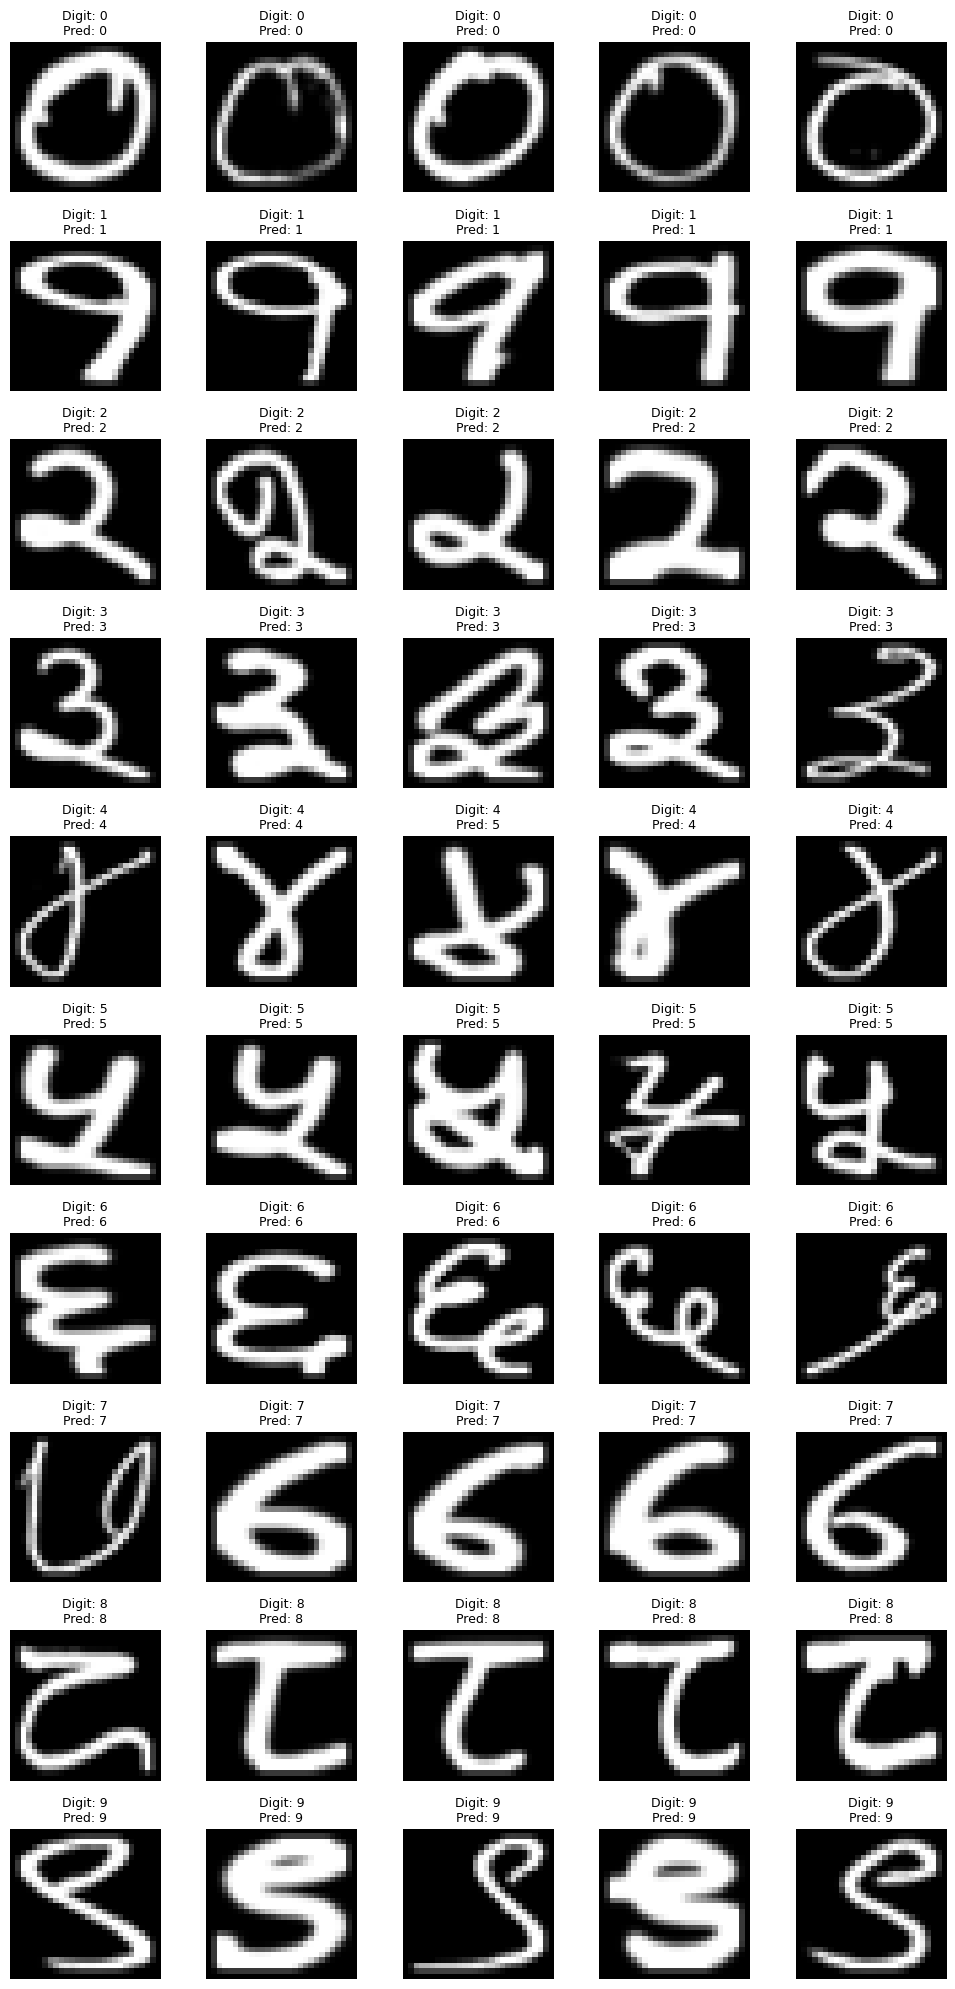

In [22]:
import matplotlib.pyplot as plt
import numpy as np

y_test_integers   = np.argmax(y_test, axis=1)
predictions_ints  = np.argmax(loaded_model.predict(x_test), axis=1)

# Show 5 examples for each digit: 10 rows x 5 columns
plt.figure(figsize=(10, 20))
for i in range(10):
    idxs = np.where(y_test_integers == i)[0]
    for j in range(5):
        if j < len(idxs):
            idx = idxs[j]
            plt.subplot(10, 5, i * 5 + j + 1)
            plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
            plt.title(f'Digit: {i}\nPred: {predictions_ints[idx]}', fontsize=9)
            plt.axis('off')

plt.tight_layout()
plt.show()